**Description**
**action**: [K1_t, K2_t, K3_t, K4_t, K5_t, K6_t, d_t] (7D), K1-K6 are stiffness, d is damping factor, take the damping matrix to be [B1_t, B2_t, B3_t, B4_t, B5_t, B6_t] = d_t * sqrt(K_t)
**state**: [e_t] (6D) tracking error e, the final goal is to reach the desired position-the hole, whose location and orientation is not fixed

**mission**: use adversial inverse reinforcement learning to train the reward function of this peg in hole task.

since we are using position control robot, we should use admittance control. 
- e_t stands for the admittance dynamics, M * e'' + B * e' + K * e = F_external

and for the actions, K should be a 6 * 6 matrix, for simplicity, we consider it a diagonal matrix made of 6 components, so is B. The mass matrix is diagonal as well, and is given in advance.

Adversial Inverse Reinforcement Learning: 

Input expert demo trajectory
• collect expert demostration trajectory \tau_i^D (provided in mujoco_wrappers/data/expert_demostration.pkl)

Initialize
• randomly initialize policy $ \pi (s,a) $ and reward function $ r_\theta(s,a) $ 。

Training Loop（Iterations $ k = 1 \dots K $ ）
• Step A： Sample the trajectory
 collect trajectory $ \tau_i $ under policy $ \pi (s,a) $ 

• Step B：Update reward function $ r_\theta(s,a) $ by minimizing Loss function $ L(\theta) $

Define discriminator：
$$
D_\theta(o,a) = \frac{\exp(r_\theta(o,a))}{\exp(r_\theta(o,a)) + \pi(a|o)}
$$
minimizing Loss function：
$$
L(\theta) = \sum_{t=0}^{T} \left[ -\mathbb{E}{D}[\log D_{\theta} (o_t,a_t)] - \mathbb{E}{\pi_t}[1 - \log D_{\theta} (o_t,a_t)] \right]
$$
to distinguish from expert trajectory to the policy
 
• Step C：evaluate trajectory reward 

use the updated reward function $ r_\theta'(s,a) $ to evaluate the trajectory

• Setp D：update the policy

use PPO to update policy $ \pi (s,a) $ by maximazing $ r_\theta'(s,a) $

Output
• learned gain scheduling policy $ \pi (s,a) $ and corresponding reward function $ r_\theta'(s,a) $


Under our circumstances, you need to finish writing the AIRL Algorithm, and I will provide the expert data
Notice that the reward in environment file mujoco_wrappers/env/peg_in_hole_env.py is set to be 0,which is to use the trained raward function $ r_\theta'(s,a) $ update policy.

In [2]:
"""
AIRL (Adversarial Inverse Reinforcement Learning) Trainer for Variable Admittance Control
Peg-in-Hole Task Implementation

Variable Admittance Control:
- State Space: [e_t] (6D,3 for translation, 3 for rotation) 
- Action Space: [K1, K2, K3, K4, K5, K6, d_t] (7D) impedance parameters
- Admittance dynamics: M * e'' + B * e' + K * e = F_external
- Damping matrix: B = d_t * sqrt(K)
"""

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import pickle
import matplotlib.pyplot as plt
from collections import deque
import random
from typing import Dict, List, Tuple, Optional
import logging

current_dir = os.getcwd()

if 'mujoco_wrappers' in current_dir:
    if not current_dir.endswith('mujoco_wrappers'):
        # Navigate to root
        root_path = current_dir.split('mujoco_wrappers')[0] + 'mujoco_wrappers'
        os.chdir(root_path)
        print(f"Changed working directory to: {os.getcwd()}")
else:
    print("Warning: Could not find mujoco_wrappers in current path")

# Add path for environment
sys.path.append(os.getcwd())

from envs.peg_in_hole_env import PegInHoleEnv

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Working directory: {os.getcwd()}")

Changed working directory to: /home/auksphere/robotics/mujoco_wrappers
Using device: cuda
Working directory: /home/auksphere/robotics/mujoco_wrappers


In [3]:
class RewardNetwork(nn.Module):
    """Neural network for reward function"""
    def __init__(self, state_dim=12, action_dim=7, hidden_dim=128):
        super(RewardNetwork, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        return self.net(x)

class ValueNetwork(nn.Module):
    """Neural network for the shaping value function"""
    def __init__(self, state_dim=12, hidden_dim=128):
        super(ValueNetwork, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state):
        return self.net(state)

class AIRLDiscriminator(nn.Module):
    """AIRL discriminator that learns reward function and shaping"""
    def __init__(self, state_dim=12, action_dim=7, hidden_dim=128):
        super(AIRLDiscriminator, self).__init__()
        
        self.reward_net = RewardNetwork(state_dim, action_dim, hidden_dim)
        self.value_net = ValueNetwork(state_dim, hidden_dim)
    
    def forward(self, state, action, next_state, log_prob):
        f = self.reward_net(state, action)
        v_s = self.value_net(state)
        v_next = self.value_net(next_state)
        
        f = f + 0.95 * v_next - v_s
        
        if log_prob.dim() == 1:
            log_prob = log_prob.unsqueeze(-1)
        
        discriminator_output = torch.sigmoid(f - log_prob)
        discriminator_output = torch.clamp(discriminator_output, min=1e-8, max=1-1e-8)
        
        reward = f.detach()
        return discriminator_output, reward
    
    def get_reward(self, state, action, next_state, log_prob):
        """Extract reward for RL training"""
        with torch.no_grad():
            disc_output, _ = self.forward(state, action, next_state, log_prob)
            disc_output = torch.clamp(disc_output, min=1e-8, max=1-1e-8)
            # reward = torch.log(disc_output) - torch.log(1 - disc_output)
            reward = -torch.log(1-disc_output)
            reward = torch.clamp(reward, min=-10, max=10)
        return reward.squeeze()


In [4]:
class VariableImpedancePolicy(nn.Module):
    """Policy network for impedance learning"""
    def __init__(self, state_dim=12, action_dim=7, hidden_dim=128):
        super(VariableImpedancePolicy, self).__init__()
        
        self.error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.position_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_desired_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.shared_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.stiffness_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 12)
        )
        
        self.damping_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, 2)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.8)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        with torch.no_grad():
            self.stiffness_branch[-1].weight.data *= 0.5
            self.stiffness_branch[-1].bias.data[:6] = 0.3
            self.stiffness_branch[-1].bias.data[6:] = -0.7
            
            self.damping_branch[-1].weight.data *= 0.7
            self.damping_branch[-1].bias.data[0] = 0.2
            self.damping_branch[-1].bias.data[1] = -0.5
    
    def forward(self, state):
        if torch.isnan(state).any():
            state = torch.where(torch.isnan(state), torch.zeros_like(state), state)
        
        tracking_error = state[:, :3]
        desired_position = state[:, 3:6]
        rot_error = state[:, 6:9]
        desired_rot = state[:, 9:12]
        
        error_features = self.error_encoder(tracking_error)
        position_features = self.position_encoder(desired_position)
        rot_error_features = self.rot_error_encoder(rot_error)
        rot_desired_features = self.rot_desired_encoder(desired_rot)
        
        combined_features = torch.cat(
            [error_features, position_features, rot_error_features, rot_desired_features], dim=-1
        )
        shared_features = self.shared_net(combined_features)
        
        stiffness_output = self.stiffness_branch(shared_features)
        damping_output = self.damping_branch(shared_features)
        
        stiffness_mean = stiffness_output[:, :6]
        stiffness_log_std = stiffness_output[:, 6:]
        damping_mean = damping_output[:, 0:1]
        damping_log_std = damping_output[:, 1:2]
        
        mean = torch.cat([stiffness_mean, damping_mean], dim=-1)
        log_std = torch.cat([stiffness_log_std, damping_log_std], dim=-1)
        
        mean = torch.clamp(mean, min=-2.5, max=2.5)
        log_std = torch.clamp(log_std, min=-2, max=2)
        
        return mean, log_std
    
    def sample_action(self, state):
        """Sample action with tanh squashing to [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.1, max=1.5)
        
        try:
            dist = Normal(mean, std)
            z = dist.rsample()
            action = torch.tanh(z)
            
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            log_prob = torch.clamp(log_prob, min=-12, max=12)
            
            return action, log_prob
        except Exception:
            action = torch.tanh(mean)
            log_prob = torch.zeros(action.shape[0], device=action.device)
            return action, log_prob
    
    def evaluate_action(self, state, action):
        """Evaluate log probability of given action in [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.1, max=1.5)
        
        action = torch.clamp(action, min=-0.999, max=0.999)
        z = 0.5 * torch.log((1 + action) / (1 - action + 1e-8))
        
        try:
            dist = Normal(mean, std)
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            return torch.clamp(log_prob, min=-12, max=12)
        except Exception:
            return torch.zeros(action.shape[0], device=action.device)
    
    def get_deterministic_action(self, state):
        """Deterministic action for evaluation"""
        mean, _ = self.forward(state)
        return torch.tanh(mean)


In [5]:
class ExpertDataLoader:
    """
    Load and process expert demonstration data
    Format: [e_t(3), pd_t(3), action] where:
    - e_t: tracking error (3D position) 
    - pd_t: desired position (3D position)
    - action: [K1, K2, K3, K4, K5, K6, damping_ratio] impedance parameters
    """
    def __init__(self, expert_data_path):
        self.expert_data_path = expert_data_path
        self.trajectories = []
        self.obs_stats = None
        self.act_stats = None
        self.load_expert_data()
    
    def load_expert_data(self):
        """Load expert trajectories from pickle file"""
        try:
            with open(self.expert_data_path, 'rb') as f:
                data = pickle.load(f)
            
            print(f"Loaded expert data from {self.expert_data_path}")
            
            # Expected format from vac_expert_generator.py merge
            if isinstance(data, dict) and 'observations' in data and 'actions' in data:
                observations = np.array(data['observations'])  # Shape: (N, 6) [e_t(3), pd_t(3)]
                actions = np.array(data['actions'])           # Shape: (N, 7) [K1-K6, damping]
                
                print(f"✓ Data format validated")
                print(f"✓ Observations: {observations.shape} - {data['metadata']['observation_description']}")
                print(f"✓ Actions: {actions.shape} - {data['metadata']['action_description']}")
                print(f"✓ Total samples: {len(observations)}")
                print(f"✓ Trajectories: {data['metadata']['num_trajectories']}")
                
                # Calculate statistics for normalization
                self.obs_stats = {
                    'mean': observations.mean(axis=0),
                    'std': observations.std(axis=0),
                    'min': observations.min(axis=0),
                    'max': observations.max(axis=0)
                }
                
                self.act_stats = {
                    'mean': actions.mean(axis=0),
                    'std': actions.std(axis=0),
                    'min': actions.min(axis=0),
                    'max': actions.max(axis=0)
                }
                
                # Split into trajectories based on metadata
                trajectory_indices = data['metadata']['trajectory_indices']
                num_trajectories = data['metadata']['num_trajectories']
                
                # Estimate trajectory length (assuming roughly equal lengths)
                avg_traj_len = len(observations) // num_trajectories
                
                # Create trajectories (simplified - could use actual trajectory boundaries)
                for i in range(num_trajectories):
                    start_idx = i * avg_traj_len
                    end_idx = min((i + 1) * avg_traj_len, len(observations))
                    
                    if start_idx < len(observations):
                        traj_obs = observations[start_idx:end_idx]
                        traj_acts = actions[start_idx:end_idx]
                        
                        # Create next states (shifted by 1)
                        if len(traj_obs) > 1:
                            next_states = traj_obs[1:]
                            traj_obs = traj_obs[:-1] 
                            traj_acts = traj_acts[:-1]
                        else:
                            next_states = traj_obs.copy()
                        
                        trajectory = {
                            'states': traj_obs,
                            'actions': traj_acts,
                            'next_states': next_states
                        }
                        self.trajectories.append(trajectory)
                
                print(f"✓ Created {len(self.trajectories)} trajectory segments")
                
                # Print data ranges for verification
                print(f"\nData Ranges:")
                print(f"  Tracking Error (e_t): X[{observations[:, 0].min():.3f}, {observations[:, 0].max():.3f}] Y[{observations[:, 1].min():.3f}, {observations[:, 1].max():.3f}] Z[{observations[:, 2].min():.3f}, {observations[:, 2].max():.3f}]")
                print(f"  Desired Pos (pd_t):   X[{observations[:, 3].min():.3f}, {observations[:, 3].max():.3f}] Y[{observations[:, 4].min():.3f}, {observations[:, 4].max():.3f}] Z[{observations[:, 5].min():.3f}, {observations[:, 5].max():.3f}]")
                print(f"  Stiffness K1-K3:     [{actions[:, :3].min():.0f}, {actions[:, :3].max():.0f}] N/m")
                print(f"  Stiffness K4-K6:     [{actions[:, 3:6].min():.0f}, {actions[:, 3:6].max():.0f}] Nm/rad")
                print(f"  Damping ratio:       [{actions[:, 6].min():.2f}, {actions[:, 6].max():.2f}]")
                
                # Analyze damping coefficient distribution
                damping_data = actions[:, 6]
                print(f"\nDamping coefficient analysis:")
                print(f"  Mean: {damping_data.mean():.3f}")
                print(f"  Std dev: {damping_data.std():.3f}")
                print(f"  Coefficient of variation: {damping_data.std()/damping_data.mean():.3f}")
                
            else:
                print(f"✗ Unexpected data format: {type(data)}")
                if hasattr(data, 'keys'):
                    print(f"  Available keys: {data.keys()}")
            
        except FileNotFoundError:
            print(f"✗ Expert data file {self.expert_data_path} not found!")
            print("Please ensure expert_demonstration.pkl exists in data/ directory")
        except Exception as e:
            print(f"✗ Error loading expert data: {e}")
            import traceback
            traceback.print_exc()
    
    def normalize_observations(self, obs):
        """Normalize observations for training stability"""
        if self.obs_stats is None:
            return obs
        
        # Normalize to [-1, 1] range, handle zero range to avoid division by zero
        obs_range = self.obs_stats['max'] - self.obs_stats['min']
        obs_range = np.where(obs_range == 0, 1.0, obs_range)  # Replace 0 with 1 to avoid division by zero
        obs_norm = (obs - self.obs_stats['min']) / obs_range * 2 - 1
        return obs_norm
    
    def normalize_actions(self, actions):
        """
        Enhanced action normalization with better handling for both stiffness and damping
        - Stiffness K1-K6: logarithmic normalization to enhance sensitivity to variations, mapped to [-1, 1]
        - Damping coefficient: square root transform to enhance numerical range, mapped to [-1, 1]
        """
        if self.act_stats is None:
            return actions
        
        actions_norm = actions.copy()
        
        for i in range(actions.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                # No variation in this dimension -> map to 0 in [-1, 1] space
                actions_norm[:, i] = 0.0
                continue
            
            if i < 6:  # Stiffness K1-K6 - use logarithmic normalization for better sensitivity
                epsilon = 1e-3
                actions_safe = np.maximum(actions[:, i], epsilon)
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_actions = np.log(actions_safe)
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    # Map log-scaled values to [-1, 1]
                    actions_norm[:, i] = (log_actions - log_min) / log_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
            else:  # Damping coefficient - square root transform
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_actions = np.sqrt(np.clip(actions[:, i], act_min_safe, act_max_safe))
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    actions_norm[:, i] = (sqrt_actions - sqrt_min) / sqrt_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
        
        return actions_norm
    
    def denormalize_actions(self, actions_norm):
        """
        Enhanced action denormalization: inverse of normalize_actions
        """
        if self.act_stats is None:
            return actions_norm
        
        actions = actions_norm.copy()
        
        for i in range(actions_norm.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                actions[:, i] = act_min
                continue
            
            if i < 6:  # Stiffness K1-K6 - inverse logarithmic transform from [-1, 1]
                epsilon = 1e-3
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    log_value = t * log_range + log_min
                    actions[:, i] = np.exp(log_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
            else:  # Damping coefficient - square root inverse transform from [-1, 1]
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    sqrt_value = t * sqrt_range + sqrt_min
                    actions[:, i] = np.square(sqrt_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
        
        return actions
    
    def get_expert_transitions(self, batch_size=256):
        """Get random batch of expert state-action transitions"""
        if not self.trajectories:
            return None, None, None, None
        
        states, actions, next_states = [], [], []
        
        for _ in range(batch_size):
            # Sample random trajectory
            traj = random.choice(self.trajectories)
            
            # Sample random transition from trajectory
            if len(traj['states']) > 0:
                idx = random.randint(0, len(traj['states']) - 1)
                states.append(traj['states'][idx])
                actions.append(traj['actions'][idx])
                
                if idx < len(traj['next_states']):
                    next_states.append(traj['next_states'][idx])
                else:
                    next_states.append(traj['states'][idx])  # Use same state if at end
        
        states = np.array(states)
        actions = np.array(actions)
        next_states = np.array(next_states)
        
        # Normalize data
        states = self.normalize_observations(states)
        actions = self.normalize_actions(actions)
        next_states = self.normalize_observations(next_states)
        
        return states, actions, next_states, np.ones(batch_size)  # expert labels = 1

class ReplayBuffer:
    """Experience replay buffer for policy trajectories"""
    def __init__(self, max_size=100000):
        self.max_size = max_size
        self.buffer = deque(maxlen=max_size)
    
    def add(self, state, action, next_state, reward, done, log_prob):
        self.buffer.append((state, action, next_state, reward, done, log_prob))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        states, actions, next_states, rewards, dones, log_probs = zip(*batch)
        
        return (np.array(states), np.array(actions), np.array(next_states),
                np.array(rewards), np.array(dones), np.array(log_probs))
    
    def __len__(self):
        return len(self.buffer)

In [6]:
# AIRL Algorithm Implementation)
class AIRLTrainer:
    """Adversarial Inverse Reinforcement Learning (AIRL) Trainer + on-policy PPO."""

    def __init__(
        self,
        env,
        expert_data_path,
        lr_policy=3e-4,
        lr_discriminator=5e-5,
        gamma=0.99,
        gae_lambda=0.95,
        clip_coef=0.2,
        vf_coef=0.5,
        ent_coef=0.05,
        max_grad_norm=1.0,
        # BC warmup
        bc_warmup_iters=10,
        bc_weight_start=1.0,
        bc_weight_end=0.0,
        bc_batch_size=256,
    ):
        self.env = env
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_coef = clip_coef
        self.vf_coef = vf_coef
        self.ent_coef = ent_coef
        self.max_grad_norm = max_grad_norm

        # BC schedule params
        self.bc_warmup_iters = int(bc_warmup_iters)
        self.bc_weight_start = float(bc_weight_start)
        self.bc_weight_end = float(bc_weight_end)
        self.bc_batch_size = int(bc_batch_size)

        self.policy = VariableImpedancePolicy(state_dim=12, hidden_dim=128).to(self.device)
        self.discriminator = AIRLDiscriminator(12, 7, hidden_dim=128).to(self.device)

        # Value function for PPO (separate from discriminator shaping value network)
        self.critic = ValueNetwork(state_dim=12, hidden_dim=128).to(self.device)

        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=lr_policy)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_policy)
        self.discriminator_optimizer = optim.Adam(self.discriminator.parameters(), lr=lr_discriminator)

        self.policy_scheduler = optim.lr_scheduler.StepLR(self.policy_optimizer, step_size=25, gamma=0.8)
        self.critic_scheduler = optim.lr_scheduler.StepLR(self.critic_optimizer, step_size=25, gamma=0.8)
        self.disc_scheduler = optim.lr_scheduler.StepLR(self.discriminator_optimizer, step_size=30, gamma=0.9)

        self.expert_loader = ExpertDataLoader(expert_data_path)

        # Keep replay buffer only for optional diagnostics; PPO uses fresh rollout buffer.
        self.replay_buffer = ReplayBuffer(max_size=100000)

        self.metrics = {
            'discriminator_loss': [],
            'policy_loss': [],
            'value_loss': [],
            'entropy': [],
            'bc_loss': [],
            'bc_weight': [],
            'airl_rewards': [],
            'discriminator_accuracy': [],
            'episode_airl_rewards': [],
            'expert_disc_output': [],
            'policy_disc_output': [],
            'reward_estimates': [],
        }

        self.current_iteration = 0
        self.best_airl_reward = -float('inf')
        self.best_score = -float('inf')

    class RolloutBuffer:
        def __init__(self):
            self.states = []
            self.actions = []
            self.log_probs = []
            self.rewards = []
            self.dones = []
            self.values = []
            self.next_states = []

        def add(self, state, action, log_prob, reward, done, value, next_state):
            self.states.append(state)
            self.actions.append(action)
            self.log_probs.append(log_prob)
            self.rewards.append(reward)
            self.dones.append(done)
            self.values.append(value)
            self.next_states.append(next_state)

        def to_tensors(self, device):
            states = torch.as_tensor(np.asarray(self.states), dtype=torch.float32, device=device)
            actions = torch.as_tensor(np.asarray(self.actions), dtype=torch.float32, device=device)
            log_probs = torch.as_tensor(np.asarray(self.log_probs), dtype=torch.float32, device=device)
            rewards = torch.as_tensor(np.asarray(self.rewards), dtype=torch.float32, device=device)
            dones = torch.as_tensor(np.asarray(self.dones), dtype=torch.float32, device=device)
            values = torch.as_tensor(np.asarray(self.values), dtype=torch.float32, device=device)
            next_states = torch.as_tensor(np.asarray(self.next_states), dtype=torch.float32, device=device)
            return states, actions, log_probs, rewards, dones, values, next_states

    def _current_bc_weight(self, iteration: int) -> float:
        """Linear BC weight from start->end over bc_warmup_iters."""
        if self.bc_warmup_iters <= 0:
            return 0.0
        if iteration < 0:
            return self.bc_weight_start
        if iteration >= self.bc_warmup_iters:
            return self.bc_weight_end
        frac = iteration / float(self.bc_warmup_iters)
        return (1.0 - frac) * self.bc_weight_start + frac * self.bc_weight_end

    def _compute_gae(self, rewards, dones, values, next_value):
        T = rewards.shape[0]
        advantages = torch.zeros(T, device=rewards.device)
        last_gae = 0.0
        for t in reversed(range(T)):
            nonterminal = 1.0 - dones[t]
            next_v = next_value if t == T - 1 else values[t + 1]
            delta = rewards[t] + self.gamma * next_v * nonterminal - values[t]
            last_gae = delta + self.gamma * self.gae_lambda * nonterminal * last_gae
            advantages[t] = last_gae
        returns = advantages + values
        return advantages, returns

    def collect_rollout(self, rollout_steps=4096, max_episode_steps=300):
        self.policy.eval()
        self.critic.eval()

        buf = self.RolloutBuffer()
        state, _ = self.env.reset()
        ep_airl_reward = 0.0
        ep_steps = 0

        for _ in range(rollout_steps):
            state_norm = self.expert_loader.normalize_observations(state.reshape(1, -1))[0]
            state_t = torch.as_tensor(state_norm, dtype=torch.float32, device=self.device).unsqueeze(0)

            with torch.no_grad():
                action_norm_t, log_prob_t = self.policy.sample_action(state_t)
                value_t = self.critic(state_t).squeeze(-1)

            action_norm = action_norm_t.squeeze(0).cpu().numpy()
            log_prob = float(log_prob_t.squeeze(0).cpu().numpy())
            value = float(value_t.squeeze(0).cpu().numpy())

            action_denorm = self.expert_loader.denormalize_actions(action_norm.reshape(1, -1))[0]
            next_state, _, done, truncated, _info = self.env.step(action_denorm)

            next_state_norm = self.expert_loader.normalize_observations(next_state.reshape(1, -1))[0]
            next_state_t = torch.as_tensor(next_state_norm, dtype=torch.float32, device=self.device).unsqueeze(0)

            with torch.no_grad():
                r_t = self.discriminator.get_reward(
                    state_t,
                    action_norm_t,
                    next_state_t,
                    torch.as_tensor([log_prob], dtype=torch.float32, device=self.device),
                )
                r = float(r_t.squeeze(0).cpu().numpy())

            terminal = bool(done or truncated or (ep_steps + 1) >= max_episode_steps)

            buf.add(
                state_norm,
                action_norm,
                log_prob,
                r,
                float(terminal),
                value,
                next_state_norm,
            )

            self.replay_buffer.add(state_norm, action_norm, next_state_norm, r, terminal, log_prob)

            ep_airl_reward += r
            ep_steps += 1

            state = next_state
            if terminal:
                self.metrics['episode_airl_rewards'].append(ep_airl_reward)
                self.best_airl_reward = max(self.best_airl_reward, ep_airl_reward)
                state, _ = self.env.reset()
                ep_airl_reward = 0.0
                ep_steps = 0

        self.policy.train()
        self.critic.train()
        return buf

    def update_reward(self, states, actions, log_probs, next_states, num_updates=2, batch_size=256):
        """Update discriminator using expert batch vs current policy rollout batch."""
        total_loss = 0.0
        total_accuracy = 0.0

        if states.shape[0] < batch_size:
            return 0.0, 0.5

        for _ in range(num_updates):
            expert_states, expert_actions, expert_next_states, _ = self.expert_loader.get_expert_transitions(batch_size)
            expert_states = torch.as_tensor(expert_states, dtype=torch.float32, device=self.device)
            expert_actions = torch.as_tensor(expert_actions, dtype=torch.float32, device=self.device)
            expert_next_states = torch.as_tensor(expert_next_states, dtype=torch.float32, device=self.device)

            idx = torch.randint(0, states.shape[0], (batch_size,), device=self.device)
            pol_states = states[idx]
            pol_actions = actions[idx]
            pol_next_states = next_states[idx]
            pol_log_probs = log_probs[idx]

            expert_log_probs = self.policy.evaluate_action(expert_states, expert_actions)

            expert_disc_output, _ = self.discriminator(expert_states, expert_actions, expert_next_states, expert_log_probs)
            policy_disc_output, _ = self.discriminator(pol_states, pol_actions, pol_next_states, pol_log_probs)

            expert_loss = -torch.log(expert_disc_output * 0.98 + 0.02).mean()
            policy_loss = -torch.log((1 - policy_disc_output) * 0.98 + 0.02).mean()
            discriminator_loss = expert_loss + policy_loss

            self.discriminator_optimizer.zero_grad()
            discriminator_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.discriminator.parameters(), 1.0)
            self.discriminator_optimizer.step()

            expert_correct = (expert_disc_output > 0.5).float().sum()
            policy_correct = (policy_disc_output <= 0.5).float().sum()
            accuracy = (expert_correct + policy_correct) / (2 * batch_size)

            total_loss += float(discriminator_loss.item())
            total_accuracy += float(accuracy.item())

            self.metrics['expert_disc_output'].append(float(expert_disc_output.mean().item()))
            self.metrics['policy_disc_output'].append(float(policy_disc_output.mean().item()))

        avg_loss = total_loss / num_updates
        avg_accuracy = total_accuracy / num_updates
        return avg_loss, avg_accuracy

    def ppo_update(self, rollout_buf, ppo_epochs=10, minibatch_size=256, bc_weight: float = 0.0):
        states, actions, old_log_probs, rewards, dones, values, next_states = rollout_buf.to_tensors(self.device)

        with torch.no_grad():
            last_next_state = next_states[-1].unsqueeze(0)
            next_value = self.critic(last_next_state).squeeze(-1).squeeze(0)

        advantages, returns = self._compute_gae(rewards, dones, values, next_value)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        n = states.shape[0]
        b_inds = np.arange(n)

        total_pi_loss = 0.0
        total_v_loss = 0.0
        total_entropy = 0.0
        total_bc_loss = 0.0
        num_updates = 0

        for _ in range(ppo_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, n, minibatch_size):
                end = start + minibatch_size
                mb_idx = b_inds[start:end]

                mb_states = states[mb_idx]
                mb_actions = actions[mb_idx]
                mb_old_logp = old_log_probs[mb_idx]
                mb_adv = advantages[mb_idx]
                mb_returns = returns[mb_idx]

                new_logp = self.policy.evaluate_action(mb_states, mb_actions)
                ratio = torch.exp(new_logp - mb_old_logp)

                pg_loss1 = -mb_adv * ratio
                pg_loss2 = -mb_adv * torch.clamp(ratio, 1.0 - self.clip_coef, 1.0 + self.clip_coef)
                policy_loss = torch.max(pg_loss1, pg_loss2).mean()

                new_values = self.critic(mb_states).squeeze(-1)
                value_loss = 0.5 * (mb_returns - new_values).pow(2).mean()

                mean, log_std = self.policy.forward(mb_states)
                entropy = (0.5 + 0.5 * np.log(2 * np.pi) + log_std).sum(dim=-1).mean()

                # --- BC warmup (expert supervision) ---
                bc_loss = torch.tensor(0.0, device=self.device)
                if bc_weight > 0.0:
                    expert_states, expert_actions, _, _ = self.expert_loader.get_expert_transitions(self.bc_batch_size)
                    expert_states = torch.as_tensor(expert_states, dtype=torch.float32, device=self.device)
                    expert_actions = torch.as_tensor(expert_actions, dtype=torch.float32, device=self.device)

                    # Match deterministic action (mean after tanh) to expert action (both normalized)
                    pred_actions = self.policy.get_deterministic_action(expert_states)
                    bc_loss = F.mse_loss(pred_actions, expert_actions)

                loss = policy_loss + self.vf_coef * value_loss - self.ent_coef * entropy + bc_weight * bc_loss

                self.policy_optimizer.zero_grad()
                self.critic_optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)

                self.policy_optimizer.step()
                self.critic_optimizer.step()

                total_pi_loss += float(policy_loss.item())
                total_v_loss += float(value_loss.item())
                total_entropy += float(entropy.item())
                total_bc_loss += float(bc_loss.item())
                num_updates += 1

        if num_updates > 0:
            self.metrics['policy_loss'].append(total_pi_loss / num_updates)
            self.metrics['value_loss'].append(total_v_loss / num_updates)
            self.metrics['entropy'].append(total_entropy / num_updates)
            self.metrics['bc_loss'].append(total_bc_loss / num_updates)
            self.metrics['bc_weight'].append(float(bc_weight))

        return (
            total_pi_loss / max(1, num_updates),
            total_v_loss / max(1, num_updates),
            total_entropy / max(1, num_updates),
            total_bc_loss / max(1, num_updates),
        )

    def train(self, num_iterations=50, best_save_path=None):
        print(f"\n{'='*60}")
        print(f"Training iterations: {num_iterations}")
        print(f"{'='*60}")

        for iteration in range(num_iterations):
            self.current_iteration = iteration
            bc_weight = self._current_bc_weight(iteration)

            print(f"\n--- AIRL Iteration {iteration + 1}/{num_iterations} ---")
            if bc_weight > 0:
                print(f"  BC warmup: weight={bc_weight:.3f} (start={self.bc_weight_start}, end={self.bc_weight_end}, iters={self.bc_warmup_iters})")

            rollout_buf = self.collect_rollout(rollout_steps=4096)
            states, actions, log_probs, _rewards, _dones, _values, next_states = rollout_buf.to_tensors(self.device)

            disc_loss, disc_acc = self.update_reward(
                states=states,
                actions=actions,
                log_probs=log_probs,
                next_states=next_states,
                num_updates=2,
                batch_size=256,
            )
            self.metrics['discriminator_loss'].append(disc_loss)
            self.metrics['discriminator_accuracy'].append(disc_acc)

            pi_loss, v_loss, ent, bc_loss = self.ppo_update(
                rollout_buf,
                ppo_epochs=10,
                minibatch_size=256,
                bc_weight=bc_weight,
            )

            recent_airl_reward = np.mean(self.metrics['episode_airl_rewards'][-5:]) if self.metrics['episode_airl_rewards'] else 0.0
            self.metrics['airl_rewards'].append(recent_airl_reward)

            nash_distance = abs(disc_acc - 0.5)
            score = recent_airl_reward - 5.0 * nash_distance

            print(f"  PPO: pi_loss={pi_loss:.4f}, v_loss={v_loss:.4f}, entropy={ent:.3f}, bc_loss={bc_loss:.4f}")
            print(f"  AIRL episode reward (recent): {recent_airl_reward:.4f} (best: {self.best_airl_reward:.4f})")
            print(f"  Discriminator: loss={disc_loss:.4f}, acc={disc_acc:.3f} (target: 0.5), Nash dist={nash_distance:.3f}")
            print(f"  Rollout steps: {len(rollout_buf.states)}")

            if (iteration + 1) % 15 == 0:
                self.policy_scheduler.step()
                self.critic_scheduler.step()
                print(f"  Policy LR: {self.policy_scheduler.get_last_lr()[0]:.2e}")

            if (iteration + 1) % 20 == 0:
                self.disc_scheduler.step()
                print(f"  Discriminator LR: {self.disc_scheduler.get_last_lr()[0]:.2e}")

            if best_save_path is not None and score > self.best_score:
                self.best_score = score
                os.makedirs(best_save_path, exist_ok=True)
                torch.save(self.policy.state_dict(), f"{best_save_path}/policy.pt")
                torch.save(self.discriminator.state_dict(), f"{best_save_path}/discriminator.pt")
                torch.save(self.critic.state_dict(), f"{best_save_path}/critic.pt")
                print(f"New best checkpoint saved (score={score:.3f})")

            if iteration % 10 == 0:
                self.monitor_impedance_parameters()

        print(f"\n{'='*60}")
        print("AIRL+PPO Training Completed")
        print(f"{'='*60}")

    def monitor_impedance_parameters(self):
        if len(self.replay_buffer) > 64:
            states, actions, _, _, _, _ = self.replay_buffer.sample(64)
            states = torch.FloatTensor(states).to(self.device)
            with torch.no_grad():
                self.policy.eval()
                pred_actions, _ = self.policy.sample_action(states)
                self.policy.train()
                pred_actions = pred_actions.cpu().numpy()
                pred_actions_denorm = self.expert_loader.denormalize_actions(pred_actions)

                stiffness_values = pred_actions_denorm[:, :6]
                damping_values = pred_actions_denorm[:, 6]
                stiffness_mean = stiffness_values.mean()
                stiffness_std = stiffness_values.std()
                stiffness_range = [stiffness_values.min(), stiffness_values.max()]
                damping_mean = damping_values.mean()
                damping_std = damping_values.std()
                damping_range = [damping_values.min(), damping_values.max()]

                print(f"  Impedance analysis:")
                print(
                    f"    Stiffness: {stiffness_mean:.0f}±{stiffness_std:.0f} N/m, "
                    f"range=[{stiffness_range[0]:.0f}, {stiffness_range[1]:.0f}]"
                )
                print(
                    f"    Damping: {damping_mean:.3f}±{damping_std:.3f}, "
                    f"range=[{damping_range[0]:.3f}, {damping_range[1]:.3f}]"
                )
                print(
                    f"    Stiffness diversity: {stiffness_std/max(1e-6, stiffness_mean):.3f}, "
                    f"Damping diversity: {damping_std/max(1e-6, damping_mean):.3f}"
                )

    def save_models(self, save_path):
        os.makedirs(save_path, exist_ok=True)
        torch.save(self.policy.state_dict(), f"{save_path}/policy.pt")
        torch.save(self.discriminator.state_dict(), f"{save_path}/discriminator.pt")
        torch.save(self.critic.state_dict(), f"{save_path}/critic.pt")

        metadata = {
            'metrics': self.metrics,
            'training_iterations': self.current_iteration,
            'best_airl_reward': self.best_airl_reward,
            'buffer_size': len(self.replay_buffer),
            'algorithm': 'AIRL',
            'final_discriminator_accuracy': self.metrics['discriminator_accuracy'][-1] if self.metrics['discriminator_accuracy'] else 0.5,
        }
        with open(f"{save_path}/training_data.pkl", 'wb') as f:
            pickle.dump(metadata, f)
        print(f"Models saved to: {save_path}")

    def plot_training_metrics(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        if self.metrics['discriminator_accuracy']:
            axes[0, 0].plot(self.metrics['discriminator_accuracy'], 'b-', linewidth=2, label='Discriminator Accuracy')
            axes[0, 0].axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Nash Equilibrium (0.5)')
            axes[0, 0].fill_between(
                range(len(self.metrics['discriminator_accuracy'])), 0.4, 0.6, alpha=0.2, color='green', label='Target Range'
            )
            axes[0, 0].set_title('Discriminator Accuracy vs Nash Equilibrium')
            axes[0, 0].set_ylabel('Accuracy')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].legend()

        if self.metrics['episode_airl_rewards']:
            axes[0, 1].plot(self.metrics['episode_airl_rewards'], alpha=0.6, color='green', label='Episode AIRL Rewards')
            if len(self.metrics['episode_airl_rewards']) > 20:
                moving_avg = np.convolve(self.metrics['episode_airl_rewards'], np.ones(20) / 20, mode='valid')
                axes[0, 1].plot(range(19, len(self.metrics['episode_airl_rewards'])), moving_avg, 'r-', linewidth=2, label='Moving Average')
                axes[0, 1].legend()
            axes[0, 1].set_title('AIRL Episode Rewards Progress')
            axes[0, 1].set_ylabel('AIRL Reward')
            axes[0, 1].grid(True, alpha=0.3)

        if self.metrics['airl_rewards']:
            axes[0, 2].plot(self.metrics['airl_rewards'], 'g-', linewidth=2)
            axes[0, 2].set_title('AIRL Rewards (rollout return proxy)')
            axes[0, 2].set_ylabel('AIRL Reward')
            axes[0, 2].grid(True, alpha=0.3)

        if self.metrics['policy_loss']:
            axes[1, 0].plot(self.metrics['policy_loss'], 'purple', linewidth=2, label='Policy loss')
            if self.metrics.get('value_loss'):
                axes[1, 0].plot(self.metrics['value_loss'], 'orange', linewidth=2, label='Value loss')
            if self.metrics.get('bc_loss'):
                axes[1, 0].plot(self.metrics['bc_loss'], 'blue', linewidth=2, alpha=0.7, label='BC loss')
            axes[1, 0].set_title('PPO Losses')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].grid(True, alpha=0.3)
            axes[1, 0].legend()

        if self.metrics['expert_disc_output'] and self.metrics['policy_disc_output']:
            axes[1, 1].plot(self.metrics['expert_disc_output'], 'b-', label='Expert Data Output', alpha=0.7)
            axes[1, 1].plot(self.metrics['policy_disc_output'], 'r-', label='Policy Data Output', alpha=0.7)
            axes[1, 1].axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Ideal Balance')
            axes[1, 1].set_title('Discriminator Output Comparison')
            axes[1, 1].set_ylabel('Discriminator Output')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)

        if self.metrics.get('bc_weight'):
            axes[1, 2].plot(self.metrics['bc_weight'], 'k-', linewidth=2)
            axes[1, 2].set_title('BC warmup weight schedule')
            axes[1, 2].set_ylabel('BC weight')
            axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.suptitle('AIRL Training Progress', y=1.02, fontsize=16)
        plt.show()


In [7]:
def main():

    print("="*60)
    print("AIRL Variable Impedance Learning")
    print("="*60)

    # Initialize environment
    try:
        env = PegInHoleEnv()
        print("✓ Environment initialized successfully")
    except Exception as e:
        print(f"✗ Environment initialization failed: {e}")
        return

    # Check expert data
    expert_data_path = "data/expert_demonstration.pkl"
    if not os.path.exists(expert_data_path):
        print(f"✗ Expert data not found: {expert_data_path}")
        print("Please run vac_expert_generator.py first to generate expert demonstrations")
        return

    print(f"Expert data found: {expert_data_path}")

    print("\nInitializing AIRL trainer")
    trainer = AIRLTrainer(
        env=env,
        expert_data_path=expert_data_path,
        lr_policy=5e-4,
        lr_discriminator=3e-5,
        ent_coef=0.05,
        bc_warmup_iters=20,
        bc_weight_start=2.0,
        bc_weight_end=0.0,
        bc_batch_size=256,
    )

    print("AIRL trainer initialized")
    print(f"  Expert trajectories loaded: {len(trainer.expert_loader.trajectories)}")
    print(f"  Device: {trainer.device}")

    # Execute AIRL training
    print(f"\nStarting AIRL training...")
    trainer.train(num_iterations=50)

    # Save trained models
    save_path = "script/models/airl"
    trainer.save_models(save_path)
    print(f"✓ Models saved to: {save_path}")

    # Display training metrics
    trainer.plot_training_metrics()

    # Variable Impedance Assessment
    print("\n" + "="*60)
    print("VARIABLE IMPEDANCE LEARNING ASSESSMENT")
    print("="*60)

    # Use actual policy inference for accurate assessment
    num_test_samples = 1000
    print(f"Testing policy on {num_test_samples} expert state samples...")

    # Sample expert states for testing
    expert_states, _, _, _ = trainer.expert_loader.get_expert_transitions(num_test_samples)

    if expert_states is not None:
        expert_states_tensor = torch.FloatTensor(expert_states).to(trainer.device)

        # Get policy actions for expert states
        with torch.no_grad():
            trainer.policy.eval()
            policy_actions = trainer.policy.get_deterministic_action(expert_states_tensor)
            trainer.policy.train()

            # Denormalize to get actual impedance parameters
            policy_actions_np = policy_actions.cpu().numpy()
            impedance_params = trainer.expert_loader.denormalize_actions(policy_actions_np)

        # Analyze impedance parameter learning
        print(f"\nActual Policy Impedance Parameter Assessment:")
        print(f"Based on deterministic policy actions on expert state distribution")

        stiffness_params = impedance_params[:, :6]  # K1-K6
        damping_params = impedance_params[:, 6]     # damping coefficient

        # Detailed stiffness analysis
        for i in range(6):
            k_values = stiffness_params[:, i]
            k_min, k_max = k_values.min(), k_values.max()
            k_mean, k_std = k_values.mean(), k_values.std()
            k_range = k_max - k_min

            print(f"  K{i+1}: [{k_min:.0f}, {k_max:.0f}] N/m, mean={k_mean:.0f}, std={k_std:.0f}, range={k_range:.0f}")

        # Overall stiffness statistics
        all_stiffness = stiffness_params.flatten()
        overall_min = all_stiffness.min()
        overall_max = all_stiffness.max()
        overall_mean = all_stiffness.mean()
        overall_std = all_stiffness.std()
        overall_range = overall_max - overall_min

        print(f"\n  Overall Stiffness Range: [{overall_min:.0f}, {overall_max:.0f}] N/m")
        print(f"  Overall Mean: {overall_mean:.0f} N/m")
        print(f"  Overall Std: {overall_std:.0f} N/m")
        print(f"  Total Range: {overall_range:.0f} N/m")

        # Damping analysis
        d_min, d_max = damping_params.min(), damping_params.max()
        d_mean, d_std = damping_params.mean(), damping_params.std()
        d_range = d_max - d_min

        print(f"\n  Damping coefficient: [{d_min:.3f}, {d_max:.3f}], mean={d_mean:.3f}, std={d_std:.3f}, range={d_range:.3f}")

        # Expert data comparison for reference
        expert_stiffness_min = trainer.expert_loader.act_stats['min'][:6].min()
        expert_stiffness_max = trainer.expert_loader.act_stats['max'][:6].max()
        expert_damping_min = trainer.expert_loader.act_stats['min'][6]
        expert_damping_max = trainer.expert_loader.act_stats['max'][6]

        print(f"\n  Expert Reference:")
        print(f"    Expert Stiffness Range: [{expert_stiffness_min:.0f}, {expert_stiffness_max:.0f}] N/m")
        print(f"    Expert Damping Range: [{expert_damping_min:.3f}, {expert_damping_max:.3f}]")

        # Coverage assessment
        stiffness_coverage = (overall_max - overall_min) / (expert_stiffness_max - expert_stiffness_min) * 100
        damping_coverage = (d_max - d_min) / (expert_damping_max - expert_damping_min) * 100

        print(f"\n  Coverage Assessment:")
        print(f"    Stiffness range coverage: {stiffness_coverage:.1f}%")
        print(f"    Damping range coverage: {damping_coverage:.1f}%")

        # Learning quality assessment
        if overall_range > 200:  # Meaningful stiffness variation
            if stiffness_coverage > 90:
                stiffness_quality = "EXCELLENT"
            elif stiffness_coverage > 40:
                stiffness_quality = "GOOD"
            elif stiffness_coverage > 20:
                stiffness_quality = "FAIR"
            else:
                stiffness_quality = "POOR"
        else:
            stiffness_quality = "VERY POOR (narrow range)"

        print(f"\n  Variable Impedance Learning Quality: {stiffness_quality}")

        # Action space utilization analysis
        normalized_actions = trainer.expert_loader.normalize_actions(impedance_params)
        action_utilization = []
        for i in range(7):
            action_min = normalized_actions[:, i].min()
            action_max = normalized_actions[:, i].max()
            utilization = (action_max - action_min) * 100
            action_utilization.append(utilization)
            param_name = f"K{i+1}" if i < 6 else "Damping"
            print(f"    {param_name} action space utilization: {utilization:.1f}%")

        avg_utilization = np.mean(action_utilization)
        print(f"    Average action space utilization: {avg_utilization:.1f}%")

        if avg_utilization < 10:
            print(f"     WARNING: Policy outputs concentrated in very narrow range!")
            print(f"     This indicates the policy did not learn to utilize the full action space.")

    else:
        print("✗ Could not load expert states for assessment")

    print("\n" + "="*60)
    print("AIRL TRAINING COMPLETED")
    print("="*60)


Launching AIRL Variable Impedance Learning
AIRL Variable Impedance Learning
✓ Environment initialized successfully
Expert data found: data/expert_demonstration.pkl

Initializing AIRL trainer
Loaded expert data from data/expert_demonstration.pkl
✓ Data format validated
✓ Observations: (10981, 12) - Variable Admittance Control: [e_t(3), pd_t(3), e_r(3), rd_t(3)] where e_t=p-pd, e_r=Log(R*Rd^T) (rotvec), rd_t=rotvec(Rd)
✓ Actions: (10981, 7) - impedance_parameters: [K1, K2, K3, K4, K5, K6, damping_ratio]
✓ Total samples: 10981
✓ Trajectories: 80
✓ Created 80 trajectory segments

Data Ranges:
  Tracking Error (e_t): X[-0.383, 0.386] Y[-0.332, 0.312] Z[-0.075, 0.255]
  Desired Pos (pd_t):   X[0.000, 0.000] Y[-0.702, -0.700] Z[0.120, 0.250]
  Stiffness K1-K3:     [264, 1444] N/m
  Stiffness K4-K6:     [264, 1000] Nm/rad
  Damping ratio:       [0.10, 4.61]

Damping coefficient analysis:
  Mean: 2.012
  Std dev: 1.624
  Coefficient of variation: 0.807
AIRL trainer initialized
  Expert trajecto

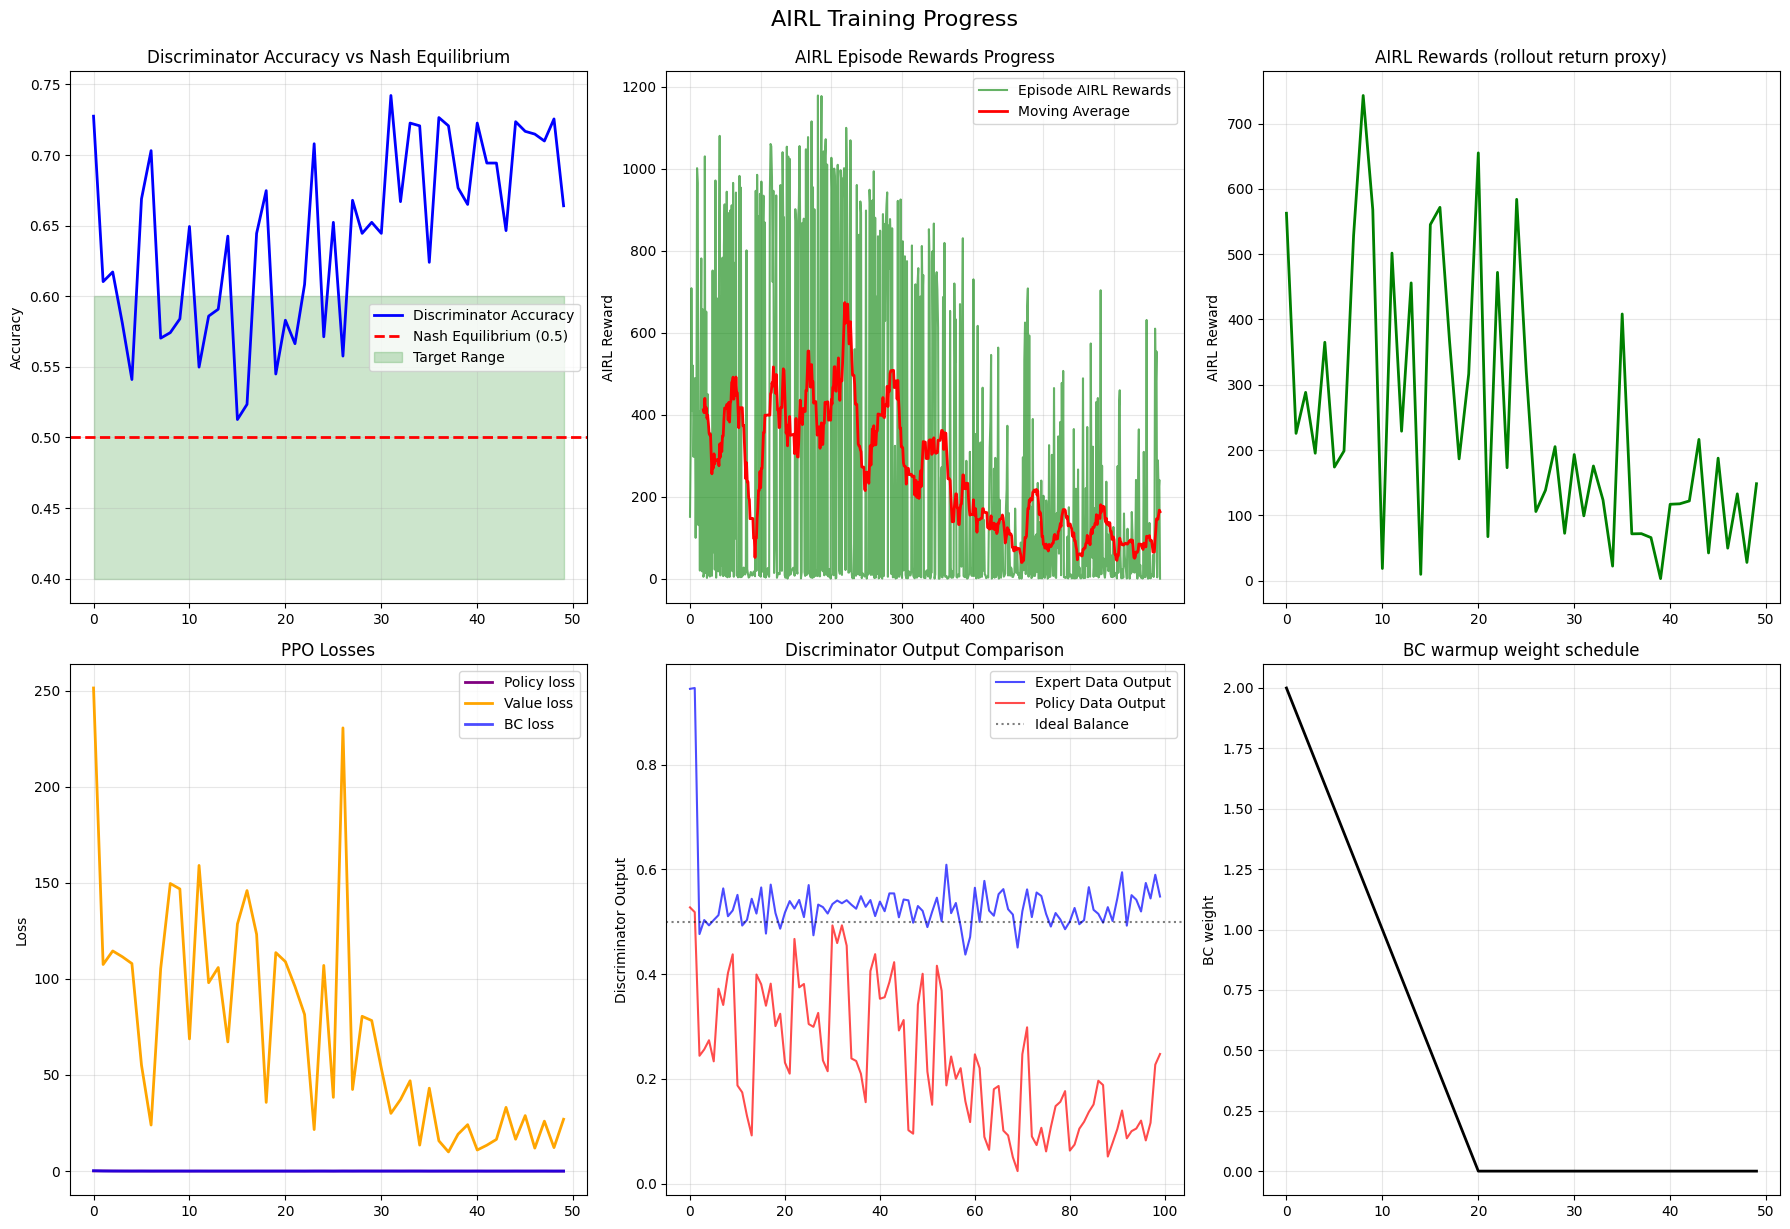


VARIABLE IMPEDANCE LEARNING ASSESSMENT
Testing policy on 1000 expert state samples...

Actual Policy Impedance Parameter Assessment:
Based on deterministic policy actions on expert state distribution
  K1: [475, 991] N/m, mean=812, std=171, range=516
  K2: [417, 991] N/m, mean=655, std=182, range=574
  K3: [803, 1103] N/m, mean=919, std=95, range=300
  K4: [370, 991] N/m, mean=749, std=213, range=621
  K5: [362, 991] N/m, mean=701, std=221, range=629
  K6: [347, 991] N/m, mean=702, std=230, range=644

  Overall Stiffness Range: [347, 1103] N/m
  Overall Mean: 756 N/m
  Overall Std: 210 N/m
  Total Range: 756 N/m

  Damping coefficient: [0.108, 2.933], mean=1.140, std=0.978, range=2.825

  Expert Reference:
    Expert Stiffness Range: [264, 1444] N/m
    Expert Damping Range: [0.100, 4.608]

  Coverage Assessment:
    Stiffness range coverage: 64.1%
    Damping range coverage: 62.7%

  Variable Impedance Learning Quality: GOOD
    K1 action space utilization: 110.5%
    K2 action space

In [8]:
print("Launching AIRL Variable Impedance Learning")
main()